<a href="https://colab.research.google.com/github/Greeshu-09/AISECT-AIML/blob/main/CNN_Cat_and_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import zipfile, os


In [2]:
# Replace 'dataset.zip' with your file name
zip_ref = zipfile.ZipFile("/content/cat & dog dataset.zip", 'r')
zip_ref.extractall("dataset")
zip_ref.close()

# Check extracted folders
os.listdir("dataset")

['cats_set', 'dogs_set']

In [3]:
img_size = (180, 180)   # Resize all images
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.


In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 1000 files belonging to 2 classes.
Using 200 files for validation.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [6]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [7]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(180, 180, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.4707 - loss: 0.8529 - val_accuracy: 0.4350 - val_loss: 0.6973
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.5160 - loss: 0.6899 - val_accuracy: 0.5800 - val_loss: 0.6864
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.5477 - loss: 0.6865 - val_accuracy: 0.4400 - val_loss: 0.7374
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.5562 - loss: 0.6854 - val_accuracy: 0.4700 - val_loss: 0.7073
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.6079 - loss: 0.6403 - val_accuracy: 0.6100 - val_loss: 0.6679
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.7054 - loss: 0.5834 - val_accuracy: 0.6350 - val_loss: 0.6615
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7698 - loss: 0.4786 - val_accuracy: 0.6200 - val_loss: 0.6982
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.8281 - loss: 0.3843 - val_accuracy: 0.6450 - val_loss:

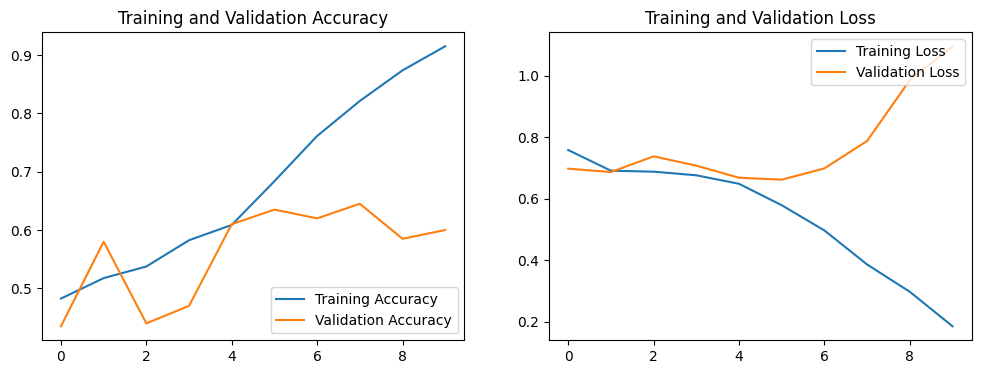

In [9]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()


In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load and preprocess image (match training size: 180x180)
img = image.load_img("/content/download.jpg", target_size=(180, 180))  # Use 180, not 128
img_array = image.img_to_array(img) / 255.0   # normalize
img_array = np.expand_dims(img_array, axis=0) # add batch dimension

# Make prediction
prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog 🐶")
else:
    print("Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Cat 🐱


In [18]:
# Load and preprocess image (match training size: 180x180)
img = image.load_img("/content/images.jpg", target_size=(180, 180))  # Use 180, not 128
img_array = image.img_to_array(img) / 255.0   # normalize
img_array = np.expand_dims(img_array, axis=0) # add batch dimension

# Make prediction
prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog 🐶")
else:
    print("Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Dog 🐶
